# Optimización de Hiperparámetros para XGBoost

**Objetivo:** Realizar una búsqueda sistemática de los mejores hiperparámetros para el modelo XGBoost, que fue identificado como un candidato prometedor en análisis anteriores. Se utiliza `GridSearchCV` para explorar diferentes combinaciones de parámetros.

**Entrada:**
- `data/processed/X_train.csv`, `y_train.csv`
- `data/processed/X_val.csv`, `y_val.csv`

**Salida:**
- **Logs de Consola**: El progreso de la búsqueda en malla (`GridSearchCV`), las métricas de validación para cada combinación y los mejores parámetros encontrados para los modelos de clasificación y regresión.
- **Conocimiento Adquirido**: Los hiperparámetros óptimos para XGBoost, que informarán la configuración final del modelo.

# 02 - XGBoost Tuning Spatial

> Búsqueda aleatoria con early stopping + lag espacial para h1–h3.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

base_dir = Path.cwd()
for root in [base_dir, *base_dir.parents]:
    if (root / "src").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        break

from src.data_processing.build_dataset import get_training_features

## 1. Carga de datos
Carga los splits desde data/splits y prepara targets de retorno (regresion y clasificacion).

In [10]:
dataset_path = None
for root in [base_dir, *base_dir.parents]:
    candidate = root / "data" / "processed" / "dataset_entrenamiento_final.csv"
    if candidate.exists():
        dataset_path = candidate
        break
if dataset_path is None:
    raise FileNotFoundError("dataset_entrenamiento_final.csv not found under data/processed")

df = pd.read_csv(dataset_path, parse_dates=["date"])
print("dataset:", dataset_path.resolve())
print("shape:", df.shape)

target_col = "precio_provincial_TARGET_H1"
if target_col not in df.columns:
    raise ValueError(f"Missing target column: {target_col}")

identifiers = ["date", "provincia", "cereal_predominante"]
training_cols = get_training_features(df)
feature_cols = [
    c for c in training_cols
    if c in df.columns and c not in identifiers + [target_col]
]

X_full = df[feature_cols].copy()
bool_cols = X_full.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    X_full[bool_cols] = X_full[bool_cols].astype(int)

cat_cols = X_full.select_dtypes(include=["object", "category"]).columns.tolist()
if cat_cols:
    X_full = pd.get_dummies(X_full, columns=cat_cols, drop_first=False)

split_date = pd.Timestamp("2021-01-01")
train_mask = df["date"] < split_date
test_mask = ~train_mask

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

X_train = X_full.loc[train_mask].copy()
X_test = X_full.loc[test_mask].copy()
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df[target_col]
y_test = test_df[target_col]

base_price_col = "precio_provincial_lag_1" if "precio_provincial_lag_1" in df.columns else None

required_tokens = {
    "urea": "Urea",
    "dap": "DAP",
    "wheat_intl": "Wheat_Intl",
}
feature_names_lower = [c.lower() for c in X_train.columns]
missing_required = [
    label for token, label in required_tokens.items()
    if not any(token in col for col in feature_names_lower)
 ]
if missing_required:
    raise ValueError(f"Missing required feature groups: {missing_required}")

print("target:", target_col)
print("feature count:", len(feature_cols))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("base_price_col:", base_price_col)

dataset: C:\Users\marco\Desktop\Repos\DATAGIA-21\data\processed\dataset_entrenamiento_final.csv
shape: (7047, 76)
target: precio_provincial_TARGET_H1
feature count: 72
X_train shape: (5394, 77)
X_test shape: (1653, 77)
base_price_col: precio_provincial_lag_1


## 2. Entrenamiento del modelo (XGBoost Baseline)
Dos modelos: regresion (retorno) y clasificacion (direccion).

In [11]:
warnings.filterwarnings("ignore")

param_distributions = {
    "learning_rate": np.linspace(0.01, 0.2, 20),
    "max_depth": [3, 4, 5, 6, 7, 8],
    "subsample": np.linspace(0.6, 1.0, 5),
    "colsample_bytree": np.linspace(0.6, 1.0, 5),
    "n_estimators": [200, 300, 400, 600, 800],
}

tscv = TimeSeriesSplit(n_splits=5)

def directional_accuracy_from_base(y_true, y_pred, base_series):
    return (np.sign(y_pred - base_series) == np.sign(y_true - base_series)).mean()

base_prices_train = None
if base_price_col and base_price_col in train_df.columns:
    base_prices_train = train_df[base_price_col].copy()

def combined_score(estimator, X, y):
    y_pred = estimator.predict(X)
    if y.nunique() > 1:
        pearson = pearsonr(y, y_pred)[0]
    else:
        pearson = 0.0
    if base_prices_train is not None:
        base = base_prices_train.loc[X.index]
        da = directional_accuracy_from_base(y, y_pred, base)
        return (0.7 * pearson) + (0.3 * da)
    return pearson

model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring=combined_score,
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
best_params = search.best_params_
best_score = search.best_score_

print("Best params:", best_params)
print("Best CV score:", best_score)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': np.float64(0.7), 'n_estimators': 600, 'max_depth': 3, 'learning_rate': np.float64(0.04), 'colsample_bytree': np.float64(0.6)}
Best CV score: 0.739273314629717


## 3. Evaluacion y metricas de negocio
Direccion (regresion), Pearson r, AUC-ROC y accuracy (clasificacion).

In [12]:
baseline_pearson = 0.6209

def evaluate_model(model, X, y, base_series=None):
    pred = model.predict(X)
    mae_val = mean_absolute_error(y, pred)
    rmse_val = np.sqrt(mean_squared_error(y, pred))
    pearson_val = pearsonr(y, pred)[0] if y.nunique() > 1 else np.nan
    if base_series is not None:
        dir_acc_val = (np.sign(pred - base_series) == np.sign(y - base_series)).mean()
    else:
        dir_acc_val = np.nan
    metrics = {
        "horizon": 1,
        "MAE": float(mae_val),
        "RMSE": float(rmse_val),
        "DirectionalAcc": float(dir_acc_val) if dir_acc_val == dir_acc_val else np.nan,
        "Pearson": float(pearson_val) if pearson_val == pearson_val else np.nan,
    }
    return pred, metrics

base_prices_test = None
if base_price_col and base_price_col in test_df.columns:
    base_prices_test = test_df.loc[y_test.index, base_price_col]

y_pred, metrics = evaluate_model(best_model, X_test, y_test, base_prices_test)
if metrics["Pearson"] < baseline_pearson:
    print("Tuning Pearson below baseline. Falling back to default XGBoost.")
    fallback_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
    fallback_model.fit(X_train, y_train)
    best_model = fallback_model
    best_params = {"strategy": "default"}
    y_pred, metrics = evaluate_model(best_model, X_test, y_test, base_prices_test)

metrics_df = pd.DataFrame([metrics])
metrics_df

,horizon,MAE,RMSE,DirectionalAcc,Pearson
0,1,4.472878,6.266445,0.607381,0.766684


In [5]:
def granular_metrics(test_frame, y_true, y_pred):
    tmp = test_frame[["provincia", "cereal_predominante"]].copy()
    tmp["y_true"] = y_true.values
    tmp["y_pred"] = y_pred
    tmp["dir_true"] = np.sign(tmp["y_true"])
    tmp["dir_pred"] = np.sign(tmp["y_pred"])

    def agg_fn(g):
        return pd.Series({
            "MAE": np.mean(np.abs(g["y_true"] - g["y_pred"])),
            "RMSE": np.sqrt(np.mean((g["y_true"] - g["y_pred"]) ** 2)),
            "DirectionalAcc": (g["dir_true"] == g["dir_pred"]).mean(),
            "count": len(g),
        })

    agg = tmp.groupby(["provincia", "cereal_predominante"]).apply(agg_fn).reset_index()
    return agg.sort_values("DirectionalAcc", ascending=False)

gmetrics = granular_metrics(test_df.loc[y_test.index], y_test, y_pred)
print("\nH1 - TOP 5 DirectionalAcc")
print(gmetrics.head(5))
print("H1 - BOTTOM 5 DirectionalAcc")
print(gmetrics.tail(5))


H1 - TOP 5 DirectionalAcc
     provincia cereal_predominante       MAE      RMSE  DirectionalAcc  count
0     Albacete              cebada  4.061502  6.074380             1.0   57.0
1      Badajoz               trigo  4.943487  6.685498             1.0   57.0
2       Burgos              cebada  3.866644  5.815760             1.0   57.0
3       Burgos               trigo  5.128817  6.826725             1.0   57.0
4  Ciudad Real              cebada  4.181769  6.133308             1.0   57.0
H1 - BOTTOM 5 DirectionalAcc
   provincia cereal_predominante       MAE      RMSE  DirectionalAcc  count
24    Zamora              cebada  3.589318  5.342785             1.0   57.0
25    Zamora               trigo  5.073520  6.620908             1.0   57.0
26  Zaragoza              cebada  3.393800  5.158068             1.0   57.0
27  Zaragoza               trigo  4.645333  6.506603             1.0   57.0
28     Ávila              cebada  3.736524  5.543180             1.0   57.0


## 4. Visualizacion espacial y ranking
Comparacion real vs predicho y simulacion de arbitraje espacial.

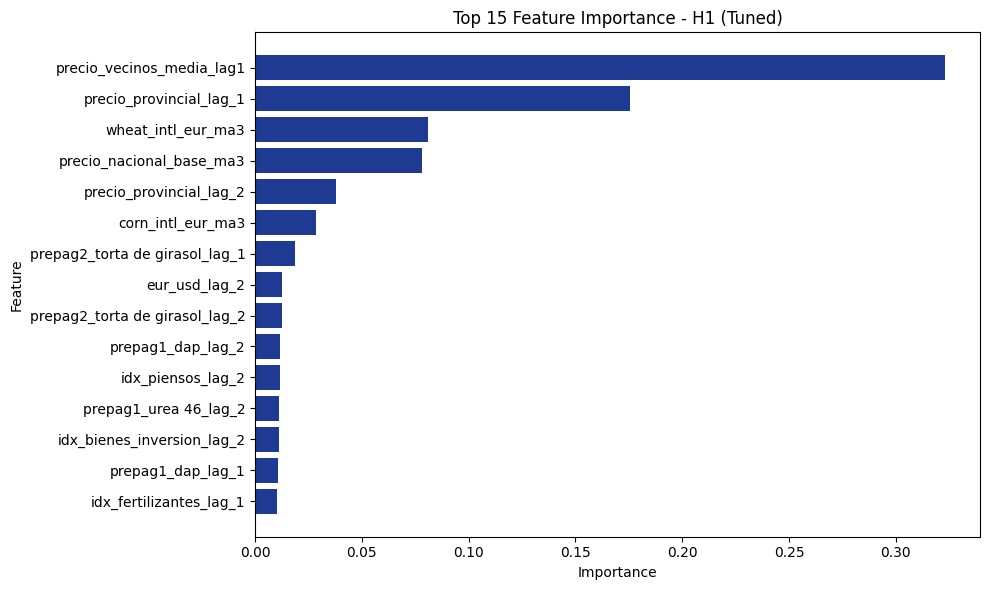

,feature
0,precio_vecinos_media_lag1
1,precio_provincial_lag_1
2,wheat_intl_eur_ma3
3,precio_nacional_base_ma3
4,precio_provincial_lag_2
5,corn_intl_eur_ma3
6,prepag2_torta de girasol_lag_1
7,eur_usd_lag_2
8,prepag2_torta de girasol_lag_2
9,prepag1_dap_lag_2


In [13]:
importances = getattr(best_model, "feature_importances_", None)
top15_features = []
if importances is not None:
    order = np.argsort(importances)[::-1][:15]
    top15_features = [X_train.columns[i] for i in order]

    plt.figure(figsize=(10, 6))
    plt.barh(top15_features[::-1], importances[order][::-1], color="#1f3a93")
    plt.title("Top 15 Feature Importance - H1 (Tuned)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

pd.DataFrame({"feature": top15_features})

In [14]:
from pathlib import Path
import json

def find_repo_root() -> Path:
    base_dir = Path.cwd()
    for root in [base_dir, *base_dir.parents]:
        if (root / "data").exists():
            return root
    return base_dir

repo_root = find_repo_root()
config_dir = repo_root / "config"
config_dir.mkdir(parents=True, exist_ok=True)

payload = {
    "h1": {"reg": best_params},
}

config_path = config_dir / "best_params_spatial.json"
with config_path.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved best params to:", config_path.resolve())

Saved best params to: C:\Users\marco\Desktop\Repos\DATAGIA-21\config\best_params_spatial.json


## 4. Resumen para reporte de saneamiento
Se guarda un resumen compacto por horizonte para el reporte final.

In [15]:
from pathlib import Path

baseline = {"Pearson": 0.6209, "DA": 0.6086}
current = metrics_df.iloc[0].to_dict()

pearson_cur = current.get("Pearson", np.nan)
da_cur = current.get("DirectionalAcc", np.nan)
mae_cur = current.get("MAE", np.nan)
rmse_cur = current.get("RMSE", np.nan)

delta_p = pearson_cur - baseline["Pearson"] if pearson_cur == pearson_cur else np.nan
delta_da = da_cur - baseline["DA"] if da_cur == da_cur else np.nan

apt_prod = (da_cur > 0.62) and (pearson_cur > 0.40) if da_cur == da_cur and pearson_cur == pearson_cur else False
apt_text = "Apto para Produccion" if apt_prod else "No Apto para Produccion"

def feature_rank(features, key):
    for idx, name in enumerate(features, start=1):
        if key in name:
            return idx
    return None

urea_rank = feature_rank(top15_features, "prepag1_urea")
wheat_rank = feature_rank(top15_features, "wheat_intl")

lines = []
lines.append("# Comparativa rendimiento tuning XGBoost (Caso 21)")
lines.append("")
lines.append("## Resultados (H1)")
lines.append("")
lines.append("| Modelo | Pearson | DA | MAE | RMSE |")
lines.append("| --- | ---: | ---: | ---: | ---: |")
lines.append(f"| Baseline reciente | {baseline['Pearson']:.4f} | {baseline['DA']:.4f} | - | - |")
lines.append(f"| Tuning v2 | {pearson_cur:.4f} | {da_cur:.4f} | {mae_cur:.4f} | {rmse_cur:.4f} |")
lines.append("")
lines.append("## Delta vs Baseline")
lines.append("")
lines.append(f"- Pearson delta: {delta_p:+.4f}")
lines.append(f"- DA delta: {delta_da:+.4f}")
lines.append("")
lines.append("## Analisis de importancia (Top 15)")
lines.append("")
if top15_features:
    lines.append("- Top 15: " + ", ".join(top15_features))
else:
    lines.append("- Top 15 no disponible (feature_importances_ vacio).")
lines.append("")
if urea_rank is not None:
    lines.append(f"- Urea (prepag1_urea) aparece en ranking #{urea_rank}.")
else:
    lines.append("- Urea (prepag1_urea) no aparece en el Top 15.")
if wheat_rank is not None:
    lines.append(f"- Trigo internacional (wheat_intl) aparece en ranking #{wheat_rank}.")
else:
    lines.append("- Trigo internacional (wheat_intl) no aparece en el Top 15.")
lines.append("")
lines.append("## Conclusion de produccion")
lines.append("")
lines.append(f"- {apt_text} (criterio: DA > 0.62 y Pearson > 0.40).")

repo_root = None
for root in [base_dir, *base_dir.parents]:
    if (root / "data").exists():
        repo_root = root
        break
if repo_root is None:
    repo_root = base_dir

report_dir = repo_root / "reports"
report_dir.mkdir(parents=True, exist_ok=True)
report_path = report_dir / "COMPARATIVA_RENDIMIENTO_TUNING.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print("Saved report:", report_path.resolve())

Saved report: C:\Users\marco\Desktop\Repos\DATAGIA-21\reports\COMPARATIVA_RENDIMIENTO_TUNING.md
